# EEU4C16/EEP5C16 Lab 7 - Fast Single Image Super-Resolution

## Background
Super-resolution is a technique in image and video processing whereby a low resolution (LR) image/video frame is upsampled to a higher resolution (HR). This has numerous applications for:

- Balancing image/video quality and transmission efficiency for websites.

- Upscaling of photos taken on mobile devices ([Google Research Blog - Enhance! RAISR Sharp Images with Machine Learning](https://research.google/blog/enhance-raisr-sharp-images-with-machine-learning/)).

- Upscaling of video games ([NVIDIA - DLSS 4](https://www.nvidia.com/en-us/geforce/technologies/dlss/)).

Fast super-resolution is of utmost importance for real-time applications and a number of companies are looking into this: [Qualcomm - QuickSRNet: Plain Single-Image Super-Resolution Architecture for Faster Inference on Mobile Platforms](https://openaccess.thecvf.com/content/CVPR2023W/MobileAI/papers/Berger_QuickSRNet_Plain_Single-Image_Super-Resolution_Architecture_for_Faster_Inference_on_Mobile_CVPRW_2023_paper.pdf)

## Your Task
Train a super-resolution model to up-sample image patches from $32\times32$ to $128\times128$ (a factor of $\times4$) and get as close to real-time processing as possible (take this to mean processing a $30$ $fps$ video stream which means your model inference time should be close to $1/30$ seconds $~0.03$ $s$).

**Data Pre-Processing Requirements:**

1. You will be given a training dataset that is represenatitve of the target upsampling distribution (you may want to augment this with other datasets you can find online).

2. You will have to downsample these images and use them as input to the super-resolution neural network.

3. Generate an approriate training/test split from your dataset.

**Architecture Requirements:**

1. Design and train a deep neural network architecture that finds a tradeoff between speed and accuracy.

2. You will need to implement the model class (`SuperResolutionModel`) in (`models.py`) and save the model weights as `model.pth` (**these class and filenames must be left unchanged**).

Finally you will create a report on your data processing/network design process. Try and create some nice informative graphs, images and tables for this.

## Important Notes (Read Carefully!)
- The evaluation on the server will record measures of [PSNR](https://en.wikipedia.org/wiki/Peak_signal-to-noise_ratio), [SSIM](https://en.wikipedia.org/wiki/Structural_similarity_index_measure), as well as parameter count (should be **below 5 million params**). You should talk about efficiency runtime etc. in your report. Note that you are free to consider other image quality metrics. You can do some research about these other metrics and consider them for discussion in your report. You can also consider loss functions that go beyond the simple $L_1$/$L_2$ losses.

- Note that the human visual system is more sensitive to changes in luminance
  than chrominance ([Wikipedia - Luma
  (video)](https://en.wikipedia.org/wiki/Luma_(video))). You can take advantage
  of this.

- If you choose to use you own dataset you must save it to a directory on the
  Colab VM as we have done in the cell below i.e.
  `/home/tcd/super_resolution/dataset.npz`, **DO NOT** save it anywhere in the
  `4c16-labs/code` directory as it will affect the whole git system.

- If you are making your own dataset, please chose seperate temporory working
  directory outside `4c16-labs/code`. You could make as `4c16-labs/dataset` to
  store. You CANNOT train and use dataset directly from Google Drive, you SHOULD
  move to Google Colab VM dataset (eg. `home/tcd/super_resolution` ) every session.

- There are different conventions for specifying the dimensions of input/output tensors i.e. $(B, H, W, C)$ or $(B, C, H, W)$ where:    
    - $B=$ batch index
    - $H=$ image height
    - $W=$ image width
    - $C=$ image channels (generally $3$ e.g. $RGB$, $YUV$)

- We expect your network to have $(B, C, H, W)$ (channel first convention used by torch layers) as the input and output tensor dimensions

- Your score for this lab is not directly tied to your performance on the backend. It will be a combination of your network performance and how you present your design in the interview.

In [1]:
# This cell mounts Colab to your Google Drive and navigates to the script directory
from google.colab import drive
drive.mount('/content/gdrive')
%cd /content/gdrive/MyDrive/4c16-labs/code/lab-07/

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
/content/gdrive/MyDrive/4c16-labs/code/lab-07


In [2]:
# Create a .gitignore file to avoid committing large files to git accidentlly
# You should run this cell only once at start of the lab.
# c.f. https://git-scm.com/docs/gitignore
%%writefile .gitignore
*.pyc
__pycache__/
.png
.jpg
.zip
.tar
.tar*

Overwriting .gitignore


In [ ]:
# Download the dataset (should take about ~2 minutes, 617MB)
!curl --create-dirs -o /content/gdrive/MyDrive/super_resolution/dataset.npz https://tcddeeplearning.blob.core.windows.net/deeplearning202324/hr_images.npz

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
 27  617M   27  172M    0     0  4144k      0  0:02:32  0:00:42  0:01:50 4553k

In [3]:
# Import necessary functions libraries
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# Import our model definition (if you get a module import error make sure your
# current working directory is the script directory is 4c16-labs/code/lab-07/
# from your Google Drive
from models import SuperResolutionModel

# Dataset pre-processing
Here we load the dataset we have provided from a Numpy compressed (`.npz`) file. It's up to you to pre-process the dataset.

In [15]:
import numpy as np
import torch
import os
from torch.utils.data import Dataset, DataLoader, random_split

# 1. Ensure Original Dataset exists (Download if missing)
orig_path = '/content/gdrive/MyDrive/super_resolution/dataset.npz'
if not os.path.exists(orig_path):
    print("Downloading Original Lab Dataset...")
    !curl --create-dirs -o /content/gdrive/MyDrive/super_resolution/dataset.npz https://tcddeeplearning.blob.core.windows.net/deeplearning202324/hr_images.npz

# 2. Load Datasets
print("Loading datasets...")
datasets_to_combine = []

# Load Original
data_orig = np.load(orig_path)['hr_images']
print(f"   Original Data Shape: {data_orig.shape}")
datasets_to_combine.append(data_orig)

# Load Unsplash
unsplash_path = '/content/gdrive/MyDrive/super_resolution/dataset_two.npz'
if os.path.exists(unsplash_path):
    data_unsplash = np.load(unsplash_path)['hr_images']
    print(f"   Unsplash Data Shape: {data_unsplash.shape}")
    datasets_to_combine.append(data_unsplash)
else:
    print(f"   {unsplash_path} not found. Skipping.")

# Load Sapal6
sapal_path = '/content/gdrive/MyDrive/super_resolution/dataset_three.npz'
if os.path.exists(sapal_path):
    data_sapal = np.load(sapal_path)['hr_images']
    print(f"   Sapal6 Data Shape:   {data_sapal.shape}")
    datasets_to_combine.append(data_sapal)
else:
    print(f"   {sapal_path} not found. Skipping.")

# Load DIV2K
div2k_path = '/content/gdrive/MyDrive/super_resolution/dataset_four.npz'
if os.path.exists(div2k_path):
    data_div2k = np.load(div2k_path)['hr_images']
    print(f"   DIV2K Data Shape:    {data_div2k.shape}")
    datasets_to_combine.append(data_div2k)
else:
    print(f"   {div2k_path} not found. Skipping.")

# 3. COMBINE THEM
raw_data = np.concatenate(datasets_to_combine, axis=0)
print(f"\nCOMBINED TOTAL BEFORE SHUFFLE: {raw_data.shape}")

print("Shuffling raw data to mix datasets thoroughly...")
np.random.shuffle(raw_data)

print(f"Final raw_data shape: {raw_data.shape}")

Loading datasets...
   Original Data Shape: (17354, 128, 128, 3)
   Unsplash Data Shape: (5000, 128, 128, 3)
   Sapal6 Data Shape:   (5000, 128, 128, 3)
   DIV2K Data Shape:    (9000, 128, 128, 3)

COMBINED TOTAL BEFORE SHUFFLE: (36354, 128, 128, 3)
Shuffling raw data to mix datasets thoroughly...
Final raw_data shape: (36354, 128, 128, 3)


# Defining the Dataset Generator and Dataloader
Next we define the dataloader which will give us an iterable object of high-resolution and low-resolution image pairs to use in our training loop. You can define data augmentation strategies to randomly flip image pairs, shift pixel values etc.

In [16]:
import torch
import numpy as np
from torch.utils.data import TensorDataset, DataLoader, random_split
from skimage.transform import rescale
from tqdm.auto import tqdm

# Pre-process ALL images ONCE using skimage
print("Pre-processing images with skimage (One-time setup)...")
lr_list = []
hr_list = []

for i in range(len(raw_data)):
    hr_img = raw_data[i].astype(np.float32) / 255.0

    # Downscale using skimage (Requirement satisfied)
    lr_img = rescale(hr_img, 0.25, anti_aliasing=True, channel_axis=2)

    # Append to lists
    hr_list.append(hr_img)
    lr_list.append(lr_img)

# Convert to PyTorch Tensors (Batch, Channel, Height, Width)
print("Converting to Tensors...")
# Stack into a single big tensor
lr_tensors = torch.from_numpy(np.array(lr_list)).permute(0, 3, 1, 2).float()
hr_tensors = torch.from_numpy(np.array(hr_list)).permute(0, 3, 1, 2).float()

# Create TensorDataset
full_dataset = TensorDataset(lr_tensors, hr_tensors)

# 5. Split & Loaders
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_ds, val_ds = random_split(full_dataset, [train_size, val_size])

print(f"Ready! Train size: {len(train_ds)} | Val size: {len(val_ds)}")

Pre-processing images with skimage (One-time setup)...
Converting to Tensors...
Ready! Train size: 32718 | Val size: 3636


# Next steps
*   Set up your DataLoader etc. and think about augmentations, if you want to gather more datasets for training etc.
*   Set up your model architecture and training loop to see how your initial design performs and iterate on this to increase performance.
*   You should think about how you are going to plot results and show network performance in your report.

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CharbonnierLoss(nn.Module):
    """Charbonnier Loss (L1 variation)"""
    def __init__(self, eps=1e-6):
        super(CharbonnierLoss, self).__init__()
        self.eps = eps

    def forward(self, x, y):
        diff = x - y
        # loss = sqrt(diff^2 + eps^2)
        loss = torch.mean(torch.sqrt(diff * diff + self.eps))
        return loss

class GLoss(nn.Module):
    def __init__(self):
        super().__init__()
        # Replace standard L1 with Charbonnier for better convergence
        self.charb = CharbonnierLoss()

        # 8 gradient kernels (extract differences in 8 directions)
        kernels = torch.tensor([
            [[-1, 0, 0], [0, 1, 0], [0, 0, 0]],   # Top-left
            [[0, -1, 0], [0, 1, 0], [0, 0, 0]],   # Top
            [[0, 0, -1], [0, 1, 0], [0, 0, 0]],   # Top-right
            [[0, 0, 0], [-1, 1, 0], [0, 0, 0]],   # Left
            [[0, 0, 0], [0, 1, -1], [0, 0, 0]],   # Right
            [[0, 0, 0], [0, 1, 0], [-1, 0, 0]],   # Bottom-left
            [[0, 0, 0], [0, 1, 0], [0, -1, 0]],   # Bottom
            [[0, 0, 0], [0, 1, 0], [0, 0, -1]]    # Bottom-right
        ], dtype=torch.float32)

        # Shape: (8, 1, 3, 3) for 8 gradient directions
        self.register_buffer('gradient_kernels', kernels.unsqueeze(1))

    def extract_gradient(self, x):
        """Extract gradient features using 8-directional kernels"""
        b, c, h, w = x.shape
        gradients = []

        for i in range(c):
            # Apply all 8 kernels to each channel
            grad = F.conv2d(x[:, i:i+1, :, :], self.gradient_kernels, padding=1)
            gradients.append(grad)

        # Concatenate across channels: (B, C*8, H, W)
        return torch.cat(gradients, dim=1)

    def forward(self, pred, target):
        # Pixel loss (Charbonnier)
        pixel_loss = self.charb(pred, target)

        # G1: Gradient loss at original scale
        grad_pred_1 = self.extract_gradient(pred)
        grad_target_1 = self.extract_gradient(target)
        g1_loss = self.charb(grad_pred_1, grad_target_1)

        # SG2: Gradient loss with 2x downsampling (splitting)
        # Splitting converts 128x128x3 to 64x64x12 (preserves info)
        pred_split2 = F.pixel_unshuffle(pred, 2)  # 2x downsample
        target_split2 = F.pixel_unshuffle(target, 2)
        grad_pred_2 = self.extract_gradient(pred_split2)
        grad_target_2 = self.extract_gradient(target_split2)
        sg2_loss = self.charb(grad_pred_2, grad_target_2) / 4  # Weight = 1/4

        # SG4: Gradient loss with 4x downsampling (splitting)
        pred_split4 = F.pixel_unshuffle(pred, 4)  # 4x downsample
        target_split4 = F.pixel_unshuffle(target, 4)
        grad_pred_4 = self.extract_gradient(pred_split4)
        grad_target_4 = self.extract_gradient(target_split4)
        sg4_loss = self.charb(grad_pred_4, grad_target_4) / 16  # Weight = 1/16

        # Total G-Loss: PL + G1 + SG2/4 + SG4/16
        total_loss = pixel_loss + g1_loss + sg2_loss + sg4_loss

        return total_loss

In [18]:
# --- Lab 5 Style Live Plotter with PSNR/SSIM + DATA AUGMENTATION ---
from IPython.display import clear_output
from matplotlib.ticker import MaxNLocator
import matplotlib.pyplot as plt
import importlib
import models
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import numpy as np
import torch
import torch.optim as optim
import random

# ============== NEW: Data Augmentation Dataset ==============
class SRAugmentedDataset(Dataset):
    def __init__(self, lr_images, hr_images, augment=True):
        self.lr_images = lr_images
        self.hr_images = hr_images
        self.augment = augment

    def __len__(self):
        return len(self.lr_images)

    def __getitem__(self, idx):
        lr = self.lr_images[idx]
        hr = self.hr_images[idx]

        if self.augment:
            # Random rotation (90, 180, 270 degrees)
            if random.random() > 0.5:
                k = random.choice([1, 2, 3])  # 90°, 180°, 270°
                lr = torch.rot90(lr, k, [1, 2])
                hr = torch.rot90(hr, k, [1, 2])

            # Random horizontal flip
            if random.random() > 0.5:
                lr = torch.flip(lr, [2])
                hr = torch.flip(hr, [2])

            # Random vertical flip
            if random.random() > 0.5:
                lr = torch.flip(lr, [1])
                hr = torch.flip(hr, [1])

        return lr, hr

# ============== Create Augmented Datasets ==============
# Extract tensors from your existing train_ds and val_ds
train_indices = train_ds.indices
val_indices = val_ds.indices

# Get the underlying tensors
lr_tensors = train_ds.dataset.tensors[0]
hr_tensors = train_ds.dataset.tensors[1]

train_dataset_aug = SRAugmentedDataset(
    lr_tensors[train_indices],
    hr_tensors[train_indices],
    augment=True  # Augmentation ON for training
)

val_dataset_aug = SRAugmentedDataset(
    lr_tensors[val_indices],
    hr_tensors[val_indices],
    augment=False  # Augmentation OFF for validation
)

# ============== Original Code Below ==============

# Reload the module to pick up changes
importlib.reload(models)
from models import SuperResolutionModel

batches = 64
train_loader = DataLoader(train_dataset_aug, batch_size=batches, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset_aug, batch_size=batches, shuffle=False, num_workers=0)

def calculate_metrics(pred, target):
    """Calculate PSNR and SSIM for a batch"""
    pred = pred.detach().cpu().numpy()
    target = target.detach().cpu().numpy()

    psnr_vals = []
    ssim_vals = []

    for i in range(pred.shape[0]):
        # Convert from (C, H, W) to (H, W, C)
        pred_img = np.transpose(pred[i], (1, 2, 0))
        target_img = np.transpose(target[i], (1, 2, 0))

        # Calculate metrics
        psnr_val = psnr(target_img, pred_img, data_range=1.0)
        ssim_val = ssim(target_img, pred_img, data_range=1.0, channel_axis=2)

        psnr_vals.append(psnr_val)
        ssim_vals.append(ssim_val)

    return np.mean(psnr_vals), np.mean(ssim_vals)

class PlotLogLoss:
    def __init__(self):
        self.epochs = []
        self.train_losses = []
        self.val_losses = []
        self.psnr_vals = []
        self.ssim_vals = []
        self.epoch_count = 0

    def update(self, train_loss, val_loss, psnr_val, ssim_val):
        self.epochs.append(self.epoch_count)
        self.train_losses.append(train_loss)
        self.val_losses.append(val_loss)
        self.psnr_vals.append(psnr_val)
        self.ssim_vals.append(ssim_val)
        self.epoch_count += 1

        clear_output(wait=True)
        fig, axes = plt.subplots(1, 3, figsize=(15, 4))

        # Loss plot
        axes[0].plot(self.epochs, self.train_losses, label="Train Loss")
        axes[0].plot(self.epochs, self.val_losses, label="Validation Loss")
        axes[0].xaxis.set_major_locator(MaxNLocator(integer=True))
        axes[0].set_ylabel('G Loss')
        axes[0].set_xlabel('Epoch')
        axes[0].set_title('Training Loss')
        axes[0].legend()
        axes[0].grid(True)

        # PSNR plot
        axes[1].plot(self.epochs, self.psnr_vals, 'g-')
        axes[1].xaxis.set_major_locator(MaxNLocator(integer=True))
        axes[1].set_ylabel('PSNR (dB)')
        axes[1].set_xlabel('Epoch')
        axes[1].set_title(f'PSNR: {self.psnr_vals[-1]:.2f} dB')
        axes[1].grid(True)

        # SSIM plot
        axes[2].plot(self.epochs, self.ssim_vals, 'r-')
        axes[2].xaxis.set_major_locator(MaxNLocator(integer=True))
        axes[2].set_ylabel('SSIM')
        axes[2].set_xlabel('Epoch')
        axes[2].set_title(f'SSIM: {self.ssim_vals[-1]:.4f}')
        axes[2].grid(True)

        plt.tight_layout()
        plt.show()

# Setup device and sr_model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

sr_model = SuperResolutionModel().to(device)

learning_rate = 0.0002

optimizer = optim.AdamW(sr_model.parameters(), lr=learning_rate, weight_decay=1e-4)

# SCHEDULER: Cosine Annealing with Warm Restarts
# T_0=10: First restart at epoch 10
# T_mult=2: Next restart at 10+20=30, then 30+40=70
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

plotter = PlotLogLoss()

Using device: cuda


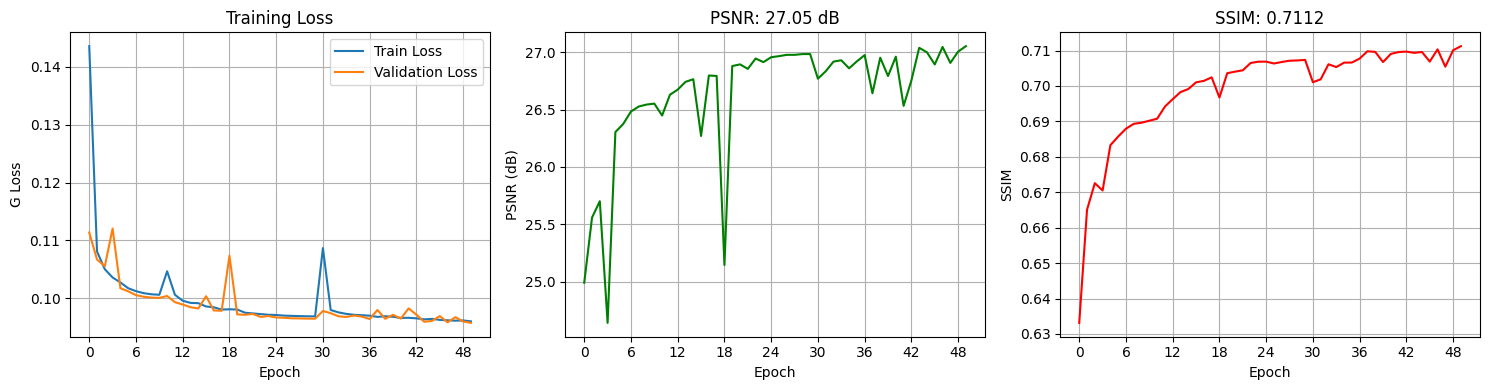

Epoch 50: Train Loss 0.09602 | Val Loss 0.09575 | PSNR 27.05 dB | SSIM 0.7112 | LR 1.00e-04
Training finished.


In [ ]:
# --- Setup Optimizer & Loss ---
num_epochs = 50
criterion = GLoss().to(device)

print("Starting training...")

# --- Main Training Loop ---
for epoch in range(num_epochs):
    sr_model.train()
    running_loss = 0.0

    # Uses the train_loader you defined in the previous cell
    for lr_batch, hr_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Train]', leave=False):
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        optimizer.zero_grad()
        out = sr_model(lr_batch)
        loss = criterion(out, hr_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * lr_batch.size(0)

    # Update Scheduler at the end of the epoch
    scheduler.step()

    train_loss = running_loss / len(train_loader.dataset)

    # Validation Phase with PSNR/SSIM
    sr_model.eval()
    val_running_loss = 0.0
    all_psnr = []
    all_ssim = []

    with torch.no_grad():
        for lr_batch, hr_batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{num_epochs} [Val]', leave=False):
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

            out = sr_model(lr_batch)

            loss = criterion(out, hr_batch)
            val_running_loss += loss.item() * lr_batch.size(0)

            # Calculate PSNR and SSIM
            psnr_val, ssim_val = calculate_metrics(out, hr_batch)
            all_psnr.append(psnr_val)
            all_ssim.append(ssim_val)

    val_loss = val_running_loss / len(val_loader.dataset)
    avg_psnr = np.mean(all_psnr)
    avg_ssim = np.mean(all_ssim)

    current_lr = optimizer.param_groups[0]['lr']

    # Update Live Graph with metrics
    plotter.update(train_loss, val_loss, avg_psnr, avg_ssim)
    print(f'Epoch {epoch+1}: Train Loss {train_loss:.5f} | Val Loss {val_loss:.5f} | PSNR {avg_psnr:.2f} dB | SSIM {avg_ssim:.4f} | LR {current_lr:.2e}')

print('Training finished.')

In [19]:
# --- RELOAD STATE CELL (Run this BEFORE the training loop) ---
import os
import torch

checkpoint_path = '/content/gdrive/MyDrive/super_resolution/full_checkpoint.pth'

if os.path.exists(checkpoint_path):
    print(f"Found checkpoint at {checkpoint_path}. Reloading states...")

    # Load the file
    checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=False)

    # 2. Restore Model & Optimizer & Scheduler
    sr_model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    # 3. Restore the Plotter (So your graph continues, not restarts)
    hist = checkpoint['plotter_history']
    plotter.epochs = hist['epochs']
    plotter.train_losses = hist['train_losses']
    plotter.val_losses = hist['val_losses']
    plotter.psnr_vals = hist['psnr_vals']
    plotter.ssim_vals = hist['ssim_vals']
    plotter.epoch_count = checkpoint['epoch']

    # 4. Tell the training loop where to start
    # (Make sure your training loop uses this 'start_epoch' variable!)
    start_epoch = checkpoint['epoch']

    print(f"Success! Resuming from Epoch {start_epoch}")
    print(f"Previous Best PSNR: {max(plotter.psnr_vals):.2f} dB")

else:
    print("No checkpoint found. Starting training from scratch (Epoch 0).")
    start_epoch = 0

Found checkpoint at /content/gdrive/MyDrive/super_resolution/full_checkpoint.pth. Reloading states...
Success! Resuming from Epoch 285
Previous Best PSNR: 27.27 dB


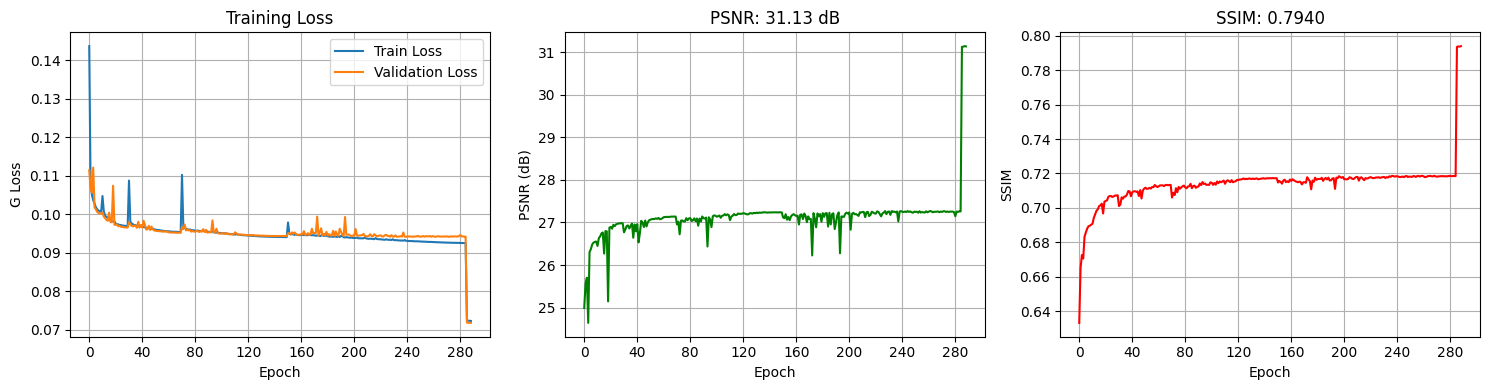

Epoch 289: Train Loss 0.07223 | Val Loss 0.07172 | PSNR 31.13 dB | SSIM 0.7940 | LR 8.48e-06


KeyboardInterrupt: 

In [20]:
# --- EXTENDED TRAINING CELL ---
# This cell resumes exactly where the previous one left off.
# It re-uses the existing 'optimizer', 'scheduler', and 'plotter'
# to preserve momentum and graph history.

# 1. Configuration
extra_epochs = 30  # How many MORE epochs you want to run
criterion = GLoss().to(device)
save_path = 'model.pth'

# 2. Detect Start Epoch from Plotter History
if len(plotter.epochs) > 0:
    start_epoch = plotter.epochs[-1] + 1
    print(f"Resuming training from Epoch {start_epoch}...")
else:
    start_epoch = 0
    print("No previous history found. Starting from Epoch 0.")

end_epoch = start_epoch + extra_epochs

# 3. Ensure Model is in Train Mode
sr_model.train()

print(f"Extending training to Epoch {end_epoch} (Cycle 3 territory)...")

# --- Main Training Loop (Continuation) ---
for epoch in range(start_epoch, end_epoch):
    sr_model.train()
    running_loss = 0.0

    # Train Loop
    for lr_batch, hr_batch in tqdm(train_loader, desc=f'Epoch {epoch+1}/{end_epoch} [Train]', leave=False):
        lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

        optimizer.zero_grad()
        out = sr_model(lr_batch)
        loss = criterion(out, hr_batch)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * lr_batch.size(0)

    # Update Scheduler (Critical for Cosine Annealing)
    scheduler.step()

    train_loss = running_loss / len(train_loader.dataset)

    # Validation Phase
    sr_model.eval()
    val_running_loss = 0.0
    all_psnr = []
    all_ssim = []

    with torch.no_grad():
        for lr_batch, hr_batch in tqdm(val_loader, desc=f'Epoch {epoch+1}/{end_epoch} [Val]', leave=False):
            lr_batch, hr_batch = lr_batch.to(device), hr_batch.to(device)

            # Standard Inference
            out = sr_model(lr_batch)

            loss = criterion(out, hr_batch)
            val_running_loss += loss.item() * lr_batch.size(0)

            # Calculate Metrics
            psnr_val, ssim_val = calculate_metrics(out, hr_batch)
            all_psnr.append(psnr_val)
            all_ssim.append(ssim_val)

    val_loss = val_running_loss / len(val_loader.dataset)
    avg_psnr = np.mean(all_psnr)
    avg_ssim = np.mean(all_ssim)

    current_lr = optimizer.param_groups[0]['lr']

    # Update the EXISTING plotter (Continues the graph)
    plotter.update(train_loss, val_loss, avg_psnr, avg_ssim)

    print(f'Epoch {epoch+1}: Train Loss {train_loss:.5f} | Val Loss {val_loss:.5f} | PSNR {avg_psnr:.2f} dB | SSIM {avg_ssim:.4f} | LR {current_lr:.2e}')

    # Save Checkpoint if it's the best so far (Simple Logic)
    # We check if current PSNR is better than the max in history
    if avg_psnr >= max(plotter.psnr_vals):
        torch.save(sr_model.state_dict(), save_path)
        # print(f"New Best Model Saved! ({avg_psnr:.2f} dB)")

print("Extended Training finished.")

In [ ]:
# --- SAVE FULL STATE (Run before disconnecting) ---
import os
from google.colab import drive

# 1. Mount Drive (if not already mounted)
if not os.path.exists('/content/gdrive'):
    drive.mount('/content/gdrive')

# 2. Define Path
checkpoint_path = '/content/gdrive/MyDrive/super_resolution/ndata_checkpoint_20112025.pth'

# 3. Bundle State
checkpoint = {
    'epoch': plotter.epochs[-1] + 1 if len(plotter.epochs) > 0 else 0,
    'model_state_dict': sr_model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict(),
    'plotter_history': {
        'epochs': plotter.epochs,
        'train_losses': plotter.train_losses,
        'val_losses': plotter.val_losses,
        'psnr_vals': plotter.psnr_vals,
        'ssim_vals': plotter.ssim_vals,
        'epoch_count': plotter.epoch_count
    }
}

# 4. Save
torch.save(checkpoint, checkpoint_path)
print(f"Full Training State saved to: {checkpoint_path}")
print(f"Last Epoch: {checkpoint['epoch']}")
print(f"Best PSNR: {max(checkpoint['plotter_history']['psnr_vals']):.2f} dB")

✅ Full Training State saved to: /content/gdrive/MyDrive/super_resolution/full_checkpoint.pth
   Last Epoch: 285
   Best PSNR: 27.27 dB
You can now safely disconnect.


# IMPORTANT
Make sure your model definition in `models.py` has the class name
`SuperResolutionModel` and make sure you save your weights as `model.pth` e.g.
`torch.save(model, 'model.pth')`.

**DO NOT** submit a model which has more than 5 Million parameters. We will
reject in the backend.

In [ ]:
def count_model_parameters(model):
  return sum(p.numel() for p in model.parameters())

total_params = count_model_parameters(sr_model)
if total_params > 5000000:
    print("Model greater than 5 million params!! Reduce model complexity!!")
else:
    print(f"Total parameters: {total_params}")
    torch.save(sr_model.state_dict(), 'model.pth')

Total parameters: 4614495


In [ ]:
!cp model.pth model_checkpoint_4.pth

Validation


Inference Stats:
Batch Size: 64
Time per image: 0.0003s
FPS: 2865.91
Real-time requirement MET (>30 FPS)


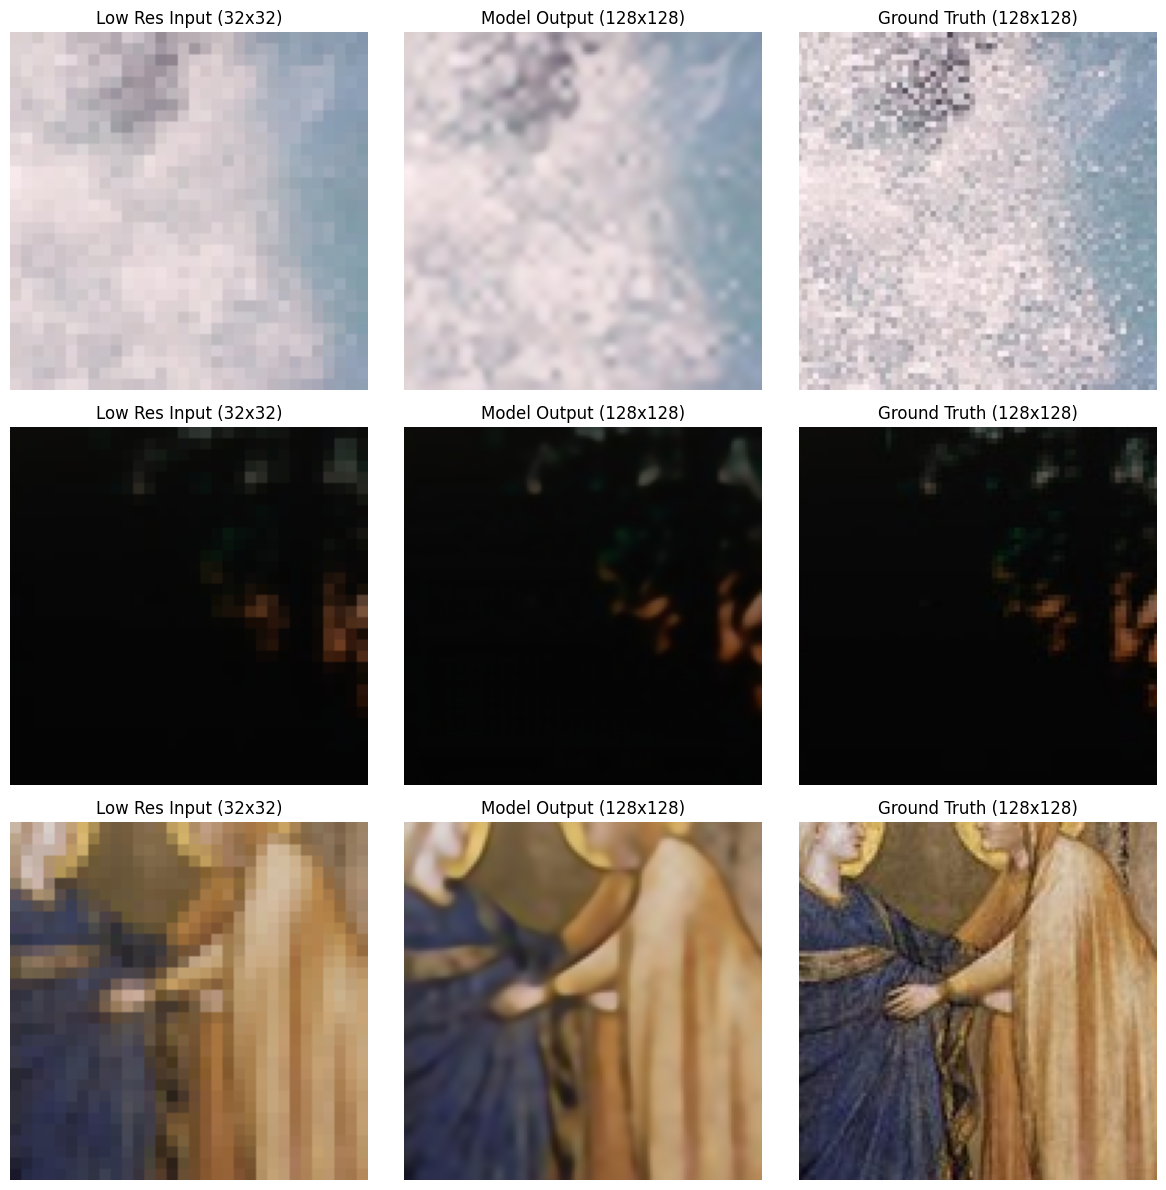

In [10]:
import torch
import matplotlib.pyplot as plt
import time
import numpy as np
import models

# Reload the module to pick up changes
importlib.reload(models)
from models import SuperResolutionModel


# Load Model
loaded_model = SuperResolutionModel()
# Load weights onto CPU first to be safe, then move to Device
loaded_model.load_state_dict(torch.load('model.pth', map_location=device))
loaded_model = loaded_model.to(device)
loaded_model.eval()

# Get a random batch from validation loader
test_lr, test_hr = next(iter(val_loader))
test_lr = test_lr.to(device)
test_hr = test_hr.to(device)

# Inference Speed Test
start_time = time.time()
with torch.no_grad():
    # Run batch inference
    test_sr = loaded_model(test_lr)
end_time = time.time()

# Calculate per-image time
total_time = end_time - start_time
time_per_img = total_time / test_lr.size(0)
fps = 1 / time_per_img

print(f"\nInference Stats:")
print(f"Batch Size: {test_lr.size(0)}")
print(f"Time per image: {time_per_img:.4f}s")
print(f"FPS: {fps:.2f}")
if time_per_img < 0.033:
    print("Real-time requirement MET (>30 FPS)")
else:
    print("Real-time requirement NOT MET (<30 FPS)")

# Visualization
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    # LR (Nearest neighbor upscale just for display comparison)
    lr_display = torch.nn.functional.interpolate(
        test_lr[i].unsqueeze(0), size=(128,128), mode='nearest'
    ).squeeze(0).cpu().permute(1, 2, 0).clamp(0, 1)

    # Model Output
    sr_display = test_sr[i].cpu().permute(1, 2, 0).clamp(0, 1)

    # Ground Truth
    hr_display = test_hr[i].cpu().permute(1, 2, 0).clamp(0, 1)

    # Plot
    axes[i, 0].imshow(lr_display)
    axes[i, 0].set_title("Low Res Input (32x32)")
    axes[i, 0].axis('off')

    axes[i, 1].imshow(sr_display)
    axes[i, 1].set_title("Model Output (128x128)")
    axes[i, 1].axis('off')

    axes[i, 2].imshow(hr_display)
    axes[i, 2].set_title("Ground Truth (128x128)")
    axes[i, 2].axis('off')

plt.tight_layout()
plt.show()